<a href="https://colab.research.google.com/github/LakshmiAhala/DataScience/blob/main/ahala_padma_fp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

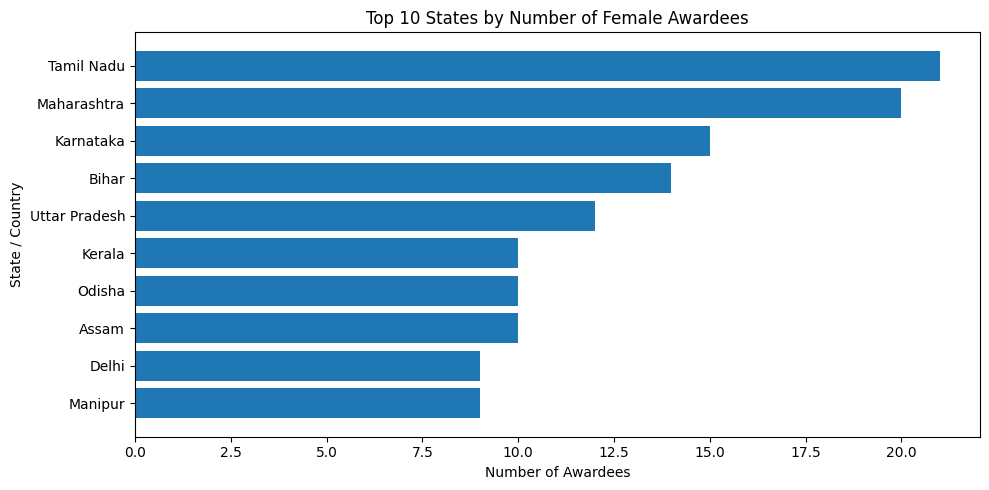

In [ ]:
#@title 9) Which are the top 10 States with the most number of female awardees?

# Filtering the DataFrame to include only female awardees
female_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Female']

# Calculating the number of female awardees for each state
state_counts_female = female_awardees_df['State / Country'].value_counts()

# Getting the top 10 states for female awardees
top_10_states_female = state_counts_female.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_states_female.index, top_10_states_female.values)
plt.xlabel('Number of Awardees')
plt.ylabel('State / Country')
plt.title('Top 10 States by Number of Female Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
#@title 10) How many foreigners have received Padma Awards? Who are they?

# Creating a list of all the featured Indian States and UTs (and their diff. spellings)
indian_states_uts = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa',
    'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala',
    'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
    'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Andaman & Nicobar',
    'Chandigarh', 'Daman & Diu', 'Delhi', 'Ladakh', 'Lakshadweep', 'Puducherry',
    'Andaman & Nicobar', 'Jammu & Kashmir', 'NCT Delhi']


# Filtering the data to get only the foreigners
foreigners_df = padmaawards_df[~padmaawards_df['State / Country'].isin(indian_states_uts)]
num_foreigners = len(foreigners_df) - 1
print('The names of the foreigners who have recieved Padma Awards: ')
display(foreigners_df)
print(f"Total Number of foreigners who received Padma Awards: {num_foreigners}")


The names of the foreigners who have recieved Padma Awards: 


,Category,SN,Name,Field,State / Country,Year,Gender
5,Padmavibhushan,6,Shri Osamu Suzuki\n(Posthumous),Trade and Industry,Japan,2025,Male
25,Padmabhushan,26,Shri Vinod Dham,Science and Engineering,United States of America,2025,Male
28,PadmaShri,29,Shri Ajay V Bhatt,Science and Engineering,United States of America,2025,Male
33,PadmaShri,34,Shri Arvind Sharma,Literature and Education,Canada,2025,Male
50,PadmaShri,51,Shri Chetan E Chitnis,Science and Engineering,France,2025,Male
...,...,...,...,...,...,...,...
1261,PadmaShri,98,Ms. Tripti Mukherjee\n(NRI/PIO),Art,United States of America,2015,Female
1262,PadmaShri,99,Dr. Dattatreyudu Nori\n(NRI/PIO),Medicine,United States of America,2015,Male
1263,PadmaShri,100,Dr. Raghu Rama Pillarisetti\n(NRI/PIO),Medicine,United States of America,2015,Male
1264,PadmaShri,101,Dr. Saumitra Rawat (NRI/PIO),Medicine,United Kingdom,2015,Male


Total Number of foreigners who received Padma Awards: 116


In [ ]:
#@title 11) Which countries are those foreigners from?

# Getting all the unique foreign countries
countries = foreigners_df['State / Country'].unique()
print('The countries the foreigners from are: ')
print(countries)


The countries the foreigners from are: 
['Japan' 'United States of America' 'Canada' 'France' 'Brazil' 'Kuwait'
 'Taiwan' 'Bangladesh' 'Papua New Guinea' 'Mexico' 'Poland'
 'United Kingdom' 'Ireland' 'Thailand' 'Russia' 'Indonesia' 'Greece'
 'Spain' 'Mauritius' 'Sri Lanka' 'Afghanistan' 'Djibouti' 'South Africa'
 'Germany' 'Philippines' 'Malaysia' 'Laos' 'Singapore' 'Cambodia'
 'Saudi Arabia' 'Myanmar' 'Brunei' 'Tajikistan' 'Nepal' 'Vietnam' 'China'
 'Serbia' 'United Arab Emirates' 'Portugal']


<ipython-input-15-62c029463167>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  posthumous_mask = padmaawards_df['Name'].str.contains("(Posthumous)", na=False)


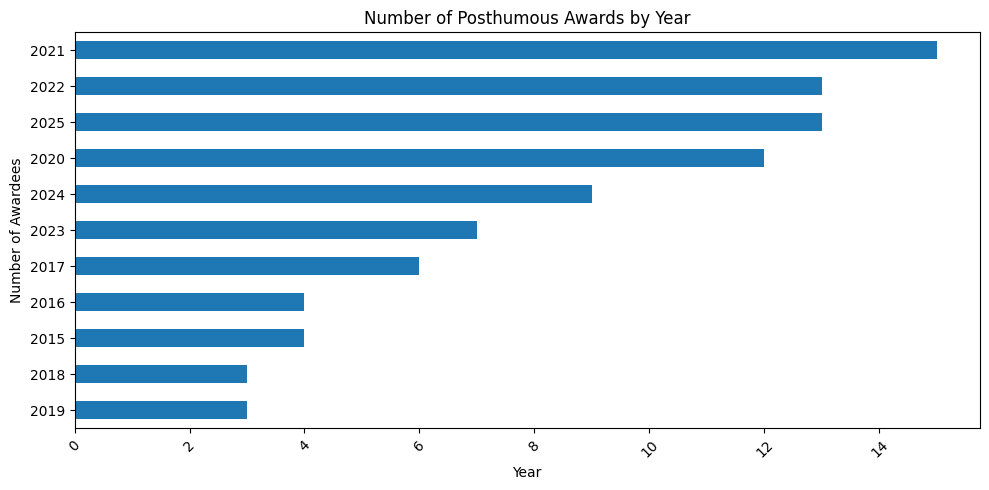

In [ ]:
#@title 12) How many awards were given posthumously?

# Creating a boolean mask where True indicates "(Posthumous)" is in the 'Name'
posthumous_mask = padmaawards_df['Name'].str.contains("(Posthumous)", na=False)

# Applying the mask to the DataFrame to get the rows with "(Posthumous)"
posthumous_df = padmaawards_df[posthumous_mask]

# Creating the horizontal bar graph
posthumous_by_year = posthumous_df.groupby('Year')['Name'].count().sort_values(ascending=False)
posthumous_by_year.plot(kind='barh', figsize=(10, 5))
plt.title('Number of Posthumous Awards by Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




Analyzing the Duos by their field



<ipython-input-16-2e7e58060ae0>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  duo_mask = padmaawards_df['Name'].str.contains("(Duo)", na=False)


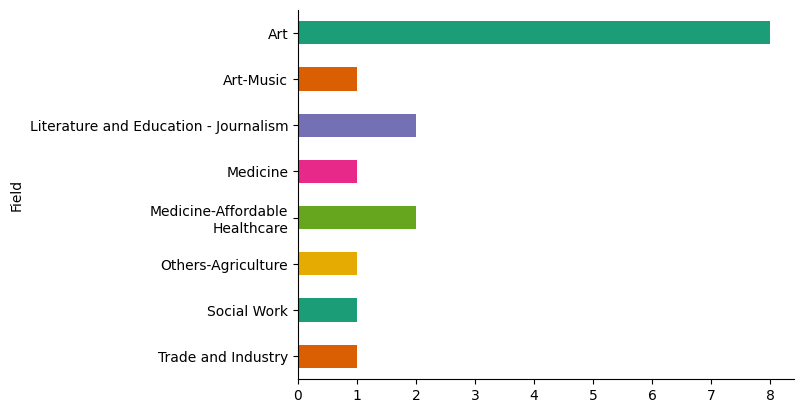

In [ ]:
#@title 13) How many duos have recieved Padma awards by field?

# Creating a boolean mask where True indicates "(Duo)" is in the 'Name'
duo_mask = padmaawards_df['Name'].str.contains("(Duo)", na=False)

# Applying the mask to the DataFrame to get the rows with "(Duo)"
duo_df = padmaawards_df[duo_mask]

# Creating a horizontal bar graph by the Field of the duos
print('\n\nAnalyzing the Duos by their field\n')
duo_df.groupby('Field').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().invert_yaxis()


In [ ]:
#@title 14) How many people have got multiple Padma awards?

# Grouping by 'Name' and count occurrences
name_counts = padmaawards_df.groupby('Name')['Name'].count()

# Filtering for counts greater than 1 (indicating multiple awards)
multiple_awards_df = name_counts[name_counts > 1]

# Getting the number of people with multiple awards
num_multiple_awards = len(multiple_awards_df)

# Printing the result
print(f"Number of people with multiple Padma awards: {num_multiple_awards}")

# Displaying the names and counts
print("\nPeople with multiple Padma awards:")
display(multiple_awards_df)


Number of people with multiple Padma awards: 2

People with multiple Padma awards:


,Name
Name,
Ms. P. V. Sindhu,2
Shri Mahesh Sharma,2


The years in the Light Blue tinge are the Election years.
The years in the Green tinge are the normal years.


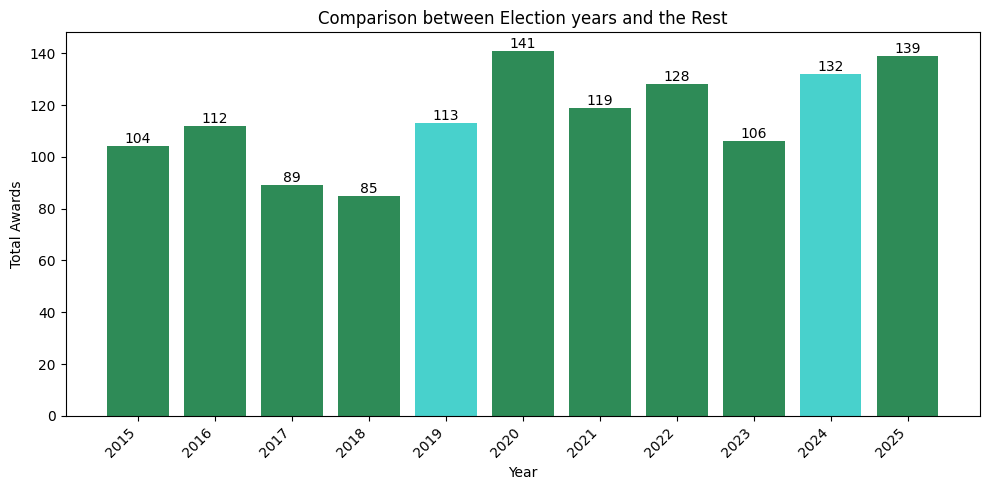

In [ ]:
#@title 15) Compare Election year(s) awards with the rest.

# Grouping data by year and count the number of awards
awards_by_year = padmaawards_df.groupby('Year')['Name'].count().reset_index()
colors_election = ['seagreen', 'seagreen', 'seagreen', 'seagreen', 'mediumturquoise',
                   'seagreen', 'seagreen', 'seagreen', 'seagreen', 'mediumturquoise', 'seagreen']
print('The years in the Light Blue tinge are the Election years.')
print('The years in the Green tinge are the normal years.')

# Creating the bar graph
plt.figure(figsize=(10, 5))  # Adjust figure size as needed
plt.bar(awards_by_year['Year'], awards_by_year['Name'], color=colors_election)
plt.xlabel("Year")
plt.ylabel("Total Awards")
plt.title("Comparison between Election years and the Rest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Getting the total number of awardees written above each bar
ax = plt.gca()

for patch in ax.patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(x, height, f'{height:.0f}', ha='center', va='bottom')
plt.show()


The years in the Green tinge are the Covid affected years.
The years in the Blue tinge are the normal years.


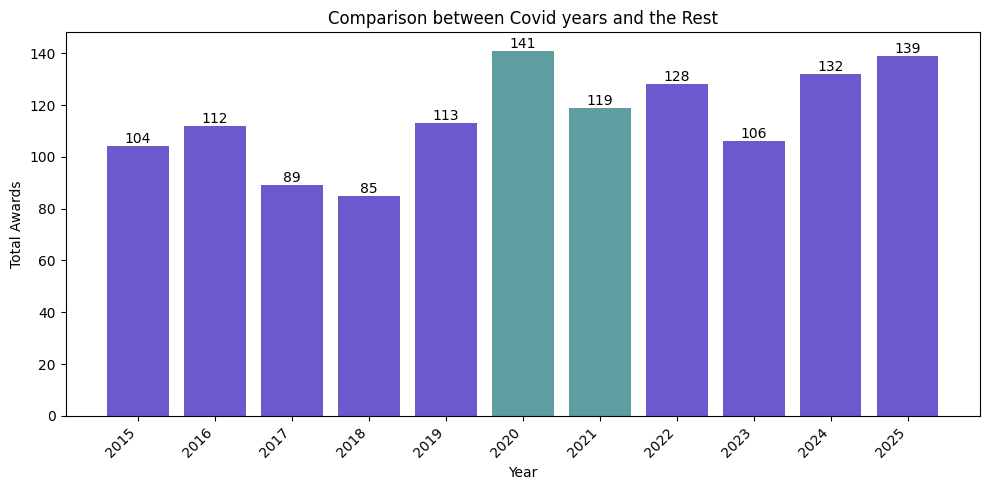

In [ ]:
#@title 16) Compare Covid year(s) awards with the rest.

# Grouping data by year and count the number of awards
awards_by_year = padmaawards_df.groupby('Year')['Name'].count().reset_index()
colors_covid = ['slateblue', 'slateblue', 'slateblue', 'slateblue', 'slateblue', 'cadetblue',
                'cadetblue', 'slateblue', 'slateblue', 'slateblue', 'slateblue']
print('The years in the Green tinge are the Covid affected years.')
print('The years in the Blue tinge are the normal years.')

# Creating the bar graph
plt.figure(figsize=(10, 5))  # Adjust figure size as needed
plt.bar(awards_by_year['Year'], awards_by_year['Name'], color=colors_covid)
plt.xlabel("Year")
plt.ylabel("Total Awards")
plt.title("Comparison between Covid years and the Rest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Getting the total number of awardees written above each bar
ax = plt.gca()

for patch in ax.patches:
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(x, height, f'{height:.0f}', ha='center', va='bottom')
plt.show()
